# 학교안전사고 EDA — 예방 관점 인사이트 탐색

**2026 학교안전사고 데이터 분석·활용 경진대회(보고서 부문)** 준비용 탐색적 분석 노트북.

- **데이터**: 학교안전공제중앙회 제공 *2021–2025 학교안전사고 발생/보상 데이터* (대회 제공, 외부 공개·재배포 금지)
- **목표**: 본격 주제 선정 전, "예방" 관점에서 스토리가 될 인사이트 후보 발굴
- **주의**: 발생 데이터의 연도 시트는 **접수연도** 기준이며, `사고연월`(실제 발생)은 과거 연도도 포함. 시계열은 `사고연월` 기준으로 필터링해 사용한다.

> 각 셀 상단 주석(`#`)에 한 줄 요약을 달았다.

## 1. 환경 설정 & 데이터 로드

In [1]:
# 공통 유틸(한글 폰트·로더) import, 그림 저장 폴더 준비
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import eda_utils as E

FIG = '../Docs/figures'
os.makedirs(FIG, exist_ok=True)
def save(name):
    plt.savefig(f'{FIG}/{name}', dpi=120, bbox_inches='tight');

occ = E.load_occ()    # 발생 (+ 사고연/월/시/방학여부 파생)
comp = E.load_comp()  # 보상 (+ 금액 숫자화, 총보상)
print('발생:', occ.shape, '| 보상:', comp.shape)

발생: (865384, 19) | 보상: (528503, 20)


## 2. 데이터 기본 파악

- 결측치·중복행 여부
- 두 데이터셋의 **조인 가능성**(공통 키) 점검

In [2]:
# 결측/중복 요약 -> 두 데이터 모두 결측 0%, 완전중복 0건 (매우 깨끗)
def quality(df, name):
    return pd.Series({
        '행수': len(df), '열수': df.shape[1],
        '총결측': int(df.isna().sum().sum()),
        '완전중복행': int(df.duplicated().sum()),
    }, name=name)
pd.concat([quality(occ,'발생'), quality(comp,'보상')], axis=1)

,발생,보상
행수,865384,528503
열수,19,20
총결측,0,0
완전중복행,0,0


In [3]:
# 조인키 점검: '구분'은 발생 A/보상 F 접두 일련번호로 서로 겹치지 않음 -> 행 단위 조인 불가
print('발생 구분 예:', occ['구분'].iloc[0], '| 고유값=', occ['구분'].nunique(), '= 행수')
print('보상 구분 예:', comp['구분'].iloc[0], '| 고유값=', comp['구분'].nunique(), '= 행수')
shared = [c for c in occ.columns if c in comp.columns and c!='구분']
print('\n공통 범주 컬럼(집계 수준 연계용):', shared)

발생 구분 예: A0000001 | 고유값= 865384 = 행수


보상 구분 예: F0000001 | 고유값= 528503 = 행수

공통 범주 컬럼(집계 수준 연계용): ['지역', '학교급', '사고자구분', '사고자학년', '사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '접수연도']


> **핵심**: 사고 ID·학교코드가 없어 **행 단위 조인은 불가**. 대신 `지역·학교급·사고자구분·학년·성별·사고시간·장소·부위·형태·활동` 10개 공통 범주로 **집계(그룹) 수준 연계**만 가능하다. 발생 빈도(발생 데이터)와 심각도·비용(보상 데이터)을 **유형별로 결합**해 해석하는 전략이 유효하다.

## 3. 범주형 변수 분포 (발생 데이터)

In [4]:
# 주요 범주 상위값 한눈에 -> 남학생 66%, 중·초 74%, '체육' 맥락 36%
CATS = ['지역','학교급','사고자성별','사고시간','사고장소','사고형태','사고부위','사고당시활동']
for c in CATS:
    top = occ[c].value_counts(normalize=True).head(5)
    print(f'[{c}]  ' + ' / '.join(f'{k} {v*100:.1f}%' for k,v in top.items()))

[지역]  경기 31.9% / 서울 15.6% / 경남 6.5% / 부산 5.4% / 인천 4.8%


[학교급]  중학교 37.6% / 초등학교 36.6% / 고등학교 19.7% / 유치원 5.4% / 특수학교 0.3%
[사고자성별]  남 66.4% / 여 33.6%


[사고시간]  체육 36.3% / 식사시간(간식 포함) 15.6% / 쉬는시간 15.5% / 방과후과정 3.6% / 그 밖의 교육활동 시간 3.6%
[사고장소]  강당(체육관) 29.1% / 운동장 27.4% / 일반(교과)교실 13.5% / 계단 6.5% / 복도 5.9%


[사고형태]  넘어짐 26.4% / 고정된 물체와의 부딪힘 19.5% / 움직이는 물체와의 부딪힘 13.7% / 스포츠 활동 중 충격을 가함 12.7% / 사람과의 부딪힘 9.1%
[사고부위]  손가락 21.2% / 발목 19.2% / 복합부위 11.6% / 무릎 5.4% / 손목 4.4%


[사고당시활동]  걷기/뛰기, 오르내리기 14.2% / 축구 12.4% / 장난, 놀이 11.7% / 농구 10.4% / 피구 7.6%


## 4. 시간축 분석
`사고연월` 기준. 접수 지연으로 과거 연도가 섞여 있어 **발생연도 2021–2025**로 한정한다.

In [5]:
# 발생연도 2021~2025 한정 데이터 준비
occ_r = occ[occ['사고연'].isin(E.RECENT_YEARS)].copy()
by_year = occ_r['사고연'].value_counts().sort_index()
print(by_year)

사고연
2021     94456
2022    150525
2023    193066
2024    210500
2025    214722
Name: count, dtype: int64


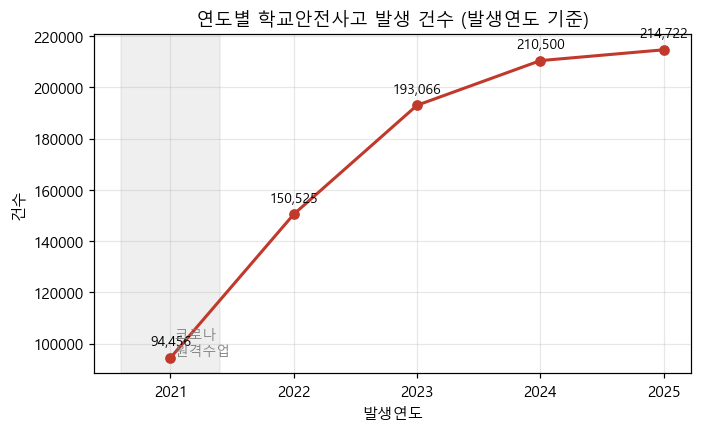

2021→2024 증가율: 123%


In [6]:
# [그림1] 연도별 발생 추이: 2021(코로나 원격수업) 저점 -> 이후 급증 회복
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(by_year.index, by_year.values, marker='o', lw=2, color='#c0392b')
for x,y in zip(by_year.index, by_year.values):
    ax.annotate(f'{y:,}', (x,y), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.axvspan(-0.4, 0.4, color='gray', alpha=0.12)
ax.text(0, by_year.min(), ' 코로나\n 원격수업', va='bottom', fontsize=9, color='gray')
ax.set_title('연도별 학교안전사고 발생 건수 (발생연도 기준)')
ax.set_ylabel('건수'); ax.set_xlabel('발생연도'); ax.grid(alpha=0.3)
save('fig01_연도추이.png'); plt.show()
print(f'2021→2024 증가율: {(by_year["2024"]/by_year["2021"]-1)*100:.0f}%')

> 2021년(코로나 원격수업)이 뚜렷한 저점. 등교 정상화와 함께 **2021→2024 약 123% 급증**. 회복·증가 추세가 강한 스토리 축.

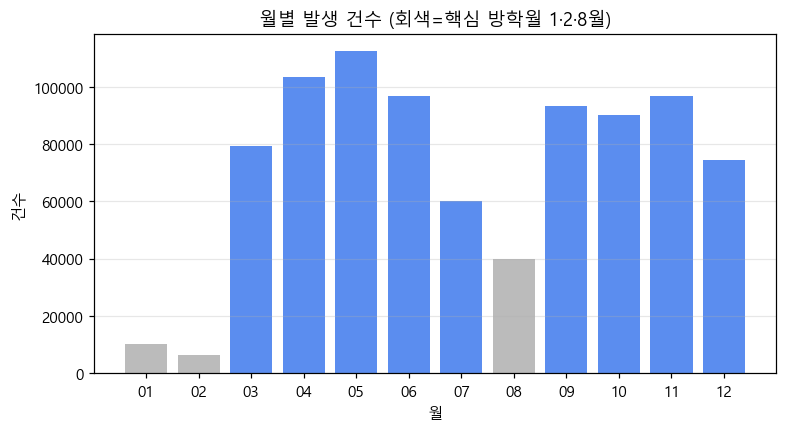

학기월 평균 89,655 vs 방학월 평균 18,790  →  방학이 79% 낮음


In [7]:
# [그림2] 월별 계절성: 학기중(3~6,9~11) 집중 / 방학(1,2,8) 급감
by_month = occ_r.groupby('사고월').size()
vac = ['01','02','08']  # 핵심 방학월
fig, ax = plt.subplots(figsize=(8,4))
colors = ['#5b8def' if m not in vac else '#bbbbbb' for m in by_month.index]
ax.bar(by_month.index, by_month.values, color=colors)
ax.set_title('월별 발생 건수 (회색=핵심 방학월 1·2·8월)')
ax.set_ylabel('건수'); ax.set_xlabel('월'); ax.grid(axis='y', alpha=0.3)
save('fig02_월별계절.png'); plt.show()
term = by_month.drop(index=vac).mean(); vaca = by_month[vac].mean()
print(f'학기월 평균 {term:,.0f} vs 방학월 평균 {vaca:,.0f}  →  방학이 {(1-vaca/term)*100:.0f}% 낮음')

> 방학월(1·2·8월) 발생이 학기월 대비 **약 70%↓**. 사고는 대부분 **학교 활동 노출량**에 비례 → 예방 자원은 학기중·특정 활동에 집중해야 함을 시사.

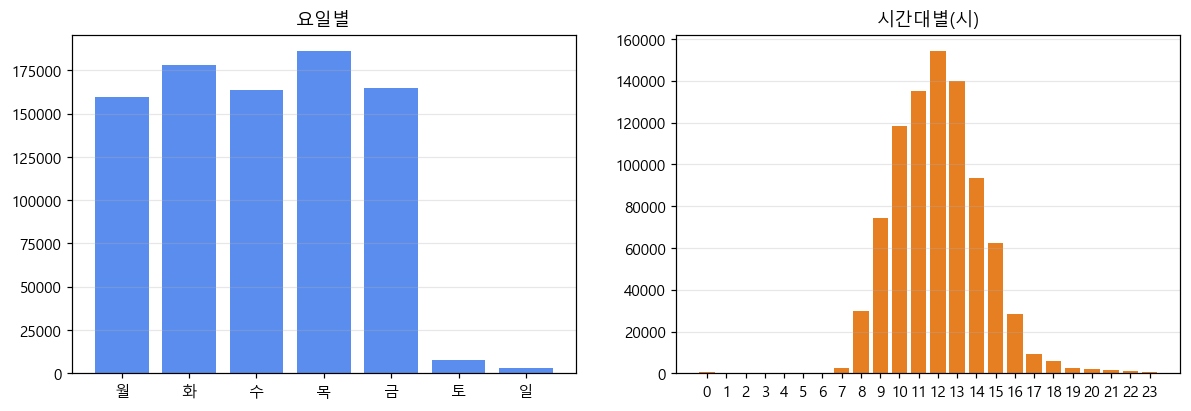

시간대 정점: 12 시 / 154,430건


In [8]:
# [그림3] 요일·시간대: 평일 균등, 점심 전후(11~13시) 정점
fig, axes = plt.subplots(1,2, figsize=(13,4))
wd = occ_r['사고요일'].value_counts().reindex(['월','화','수','목','금','토','일'])
axes[0].bar(wd.index, wd.values, color='#5b8def'); axes[0].set_title('요일별'); axes[0].grid(axis='y',alpha=0.3)
hr = occ_r.dropna(subset=['시']).groupby(occ_r['시'].astype('Int64')).size()
axes[1].bar(hr.index.astype(str), hr.values, color='#e67e22'); axes[1].set_title('시간대별(시)')
axes[1].grid(axis='y',alpha=0.3); axes[1].tick_params(axis='x', rotation=0)
save('fig03_요일시간대.png'); plt.show()
print('시간대 정점:', hr.idxmax(), '시 /', f'{hr.max():,}건')

> 주말은 거의 0(학교 기반). **11~13시(점심·4교시·체육) 집중**, 12시 최다. 시간표상 체육·점심시간 관리가 핵심 지점.

## 5. 공간 / 학교 속성별 분석

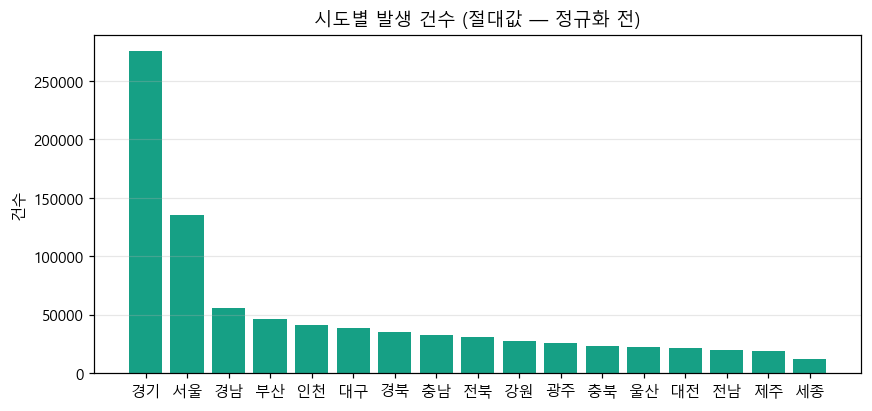

상위: 경기 31.9%, 서울 15.6%, 경남 6.5%


In [9]:
# [그림4] 지역별 건수 -- 절대건수는 학생수에 좌우됨(경기>서울) -> 정규화 필요
reg = occ['지역'].value_counts()
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(reg.index, reg.values, color='#16a085')
ax.set_title('시도별 발생 건수 (절대값 — 정규화 전)')
ax.set_ylabel('건수'); ax.grid(axis='y', alpha=0.3)
save('fig05_지역.png'); plt.show()
print('상위:', ', '.join(f'{k} {v/len(occ)*100:.1f}%' for k,v in reg.head(3).items()))

> 경기(31.9%)·서울(15.6%)이 절대건수 상위지만 이는 **학생 수 규모**를 그대로 반영. 지역 위험도 비교엔 **학생 1천명당 발생률 정규화가 필수**.
> - **권장 외부데이터**: 한국교육개발원 교육통계서비스(KESS, https://kess.kedi.re.kr) 또는 KOSIS의 *시도·학교급별 학생 수*. 시도별 발생건수 ÷ 학생수 × 1000 으로 표준화하면 "학생 규모와 무관한 위험 지역" 도출 가능.

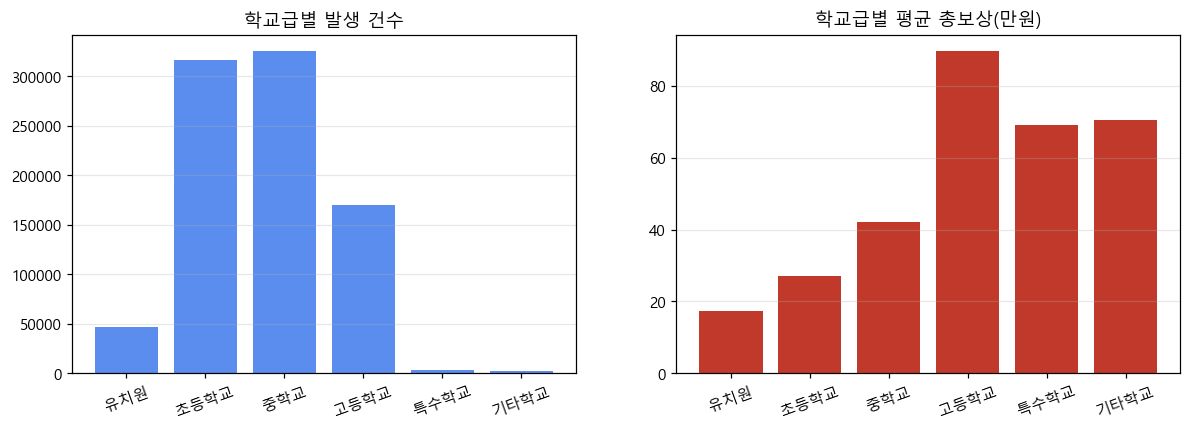

평균보상 고교/초교 배수: 3.31


In [10]:
# [그림6] 학교급: 발생 건수 vs 평균 총보상 -> 고등학교로 갈수록 '심각도'↑
order = ['유치원','초등학교','중학교','고등학교','특수학교','기타학교']
cnt = occ['학교급'].value_counts().reindex(order)
avg = comp.groupby('학교급')['총보상'].mean().reindex(order)
fig, axes = plt.subplots(1,2, figsize=(13,4))
axes[0].bar(cnt.index, cnt.values, color='#5b8def'); axes[0].set_title('학교급별 발생 건수')
axes[0].tick_params(axis='x', rotation=20); axes[0].grid(axis='y',alpha=0.3)
axes[1].bar(avg.index, avg.values/1e4, color='#c0392b'); axes[1].set_title('학교급별 평균 총보상(만원)')
axes[1].tick_params(axis='x', rotation=20); axes[1].grid(axis='y',alpha=0.3)
save('fig06_학교급.png'); plt.show()
print('평균보상 고교/초교 배수:', round(avg['고등학교']/avg['초등학교'],2))

> 발생 건수는 중·초등이 많지만 **평균 보상액은 고등학교가 초등의 3.3배**. '빈도(초·중) vs 심각도(고)'의 분리 — 예방 타깃을 어디로 둘지의 핵심 논점.

In [11]:
# 학년 분포 주의: 1~3학년 비중이 커 보이나 초·중·고에 공통 존재하는 라벨 탓(집계 착시)
occ['학교급x학년'] = occ['학교급'] + '-' + occ['사고자학년']
print(occ['사고자학년'].value_counts(normalize=True).round(3).head(7))

사고자학년
1학년    0.250
2학년    0.241
3학년    0.213
6학년    0.096
5학년    0.082
4학년    0.063
유아     0.055
Name: proportion, dtype: float64


## 6. 사고 유형 분석 (장소·형태·부위·활동)

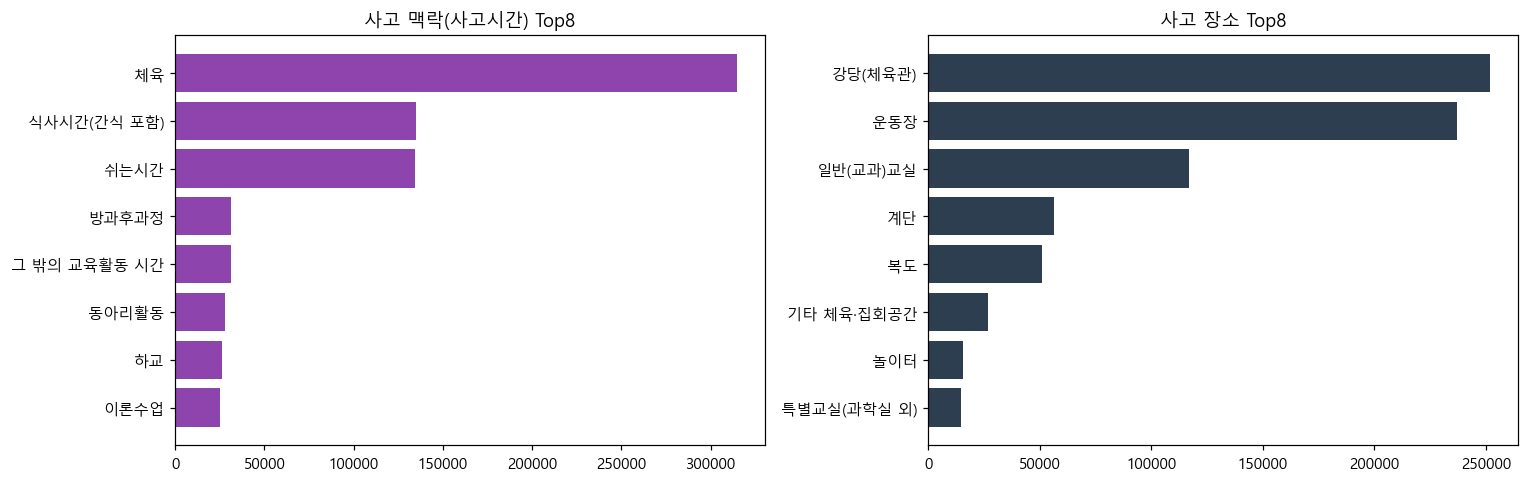

체육 맥락 비중: 36.3% | 체육관+운동장: 56.5%


In [12]:
# [그림7] 사고 맥락(사고시간) & 장소 -> '체육' + '체육관/운동장'이 압도
fig, axes = plt.subplots(1,2, figsize=(14,4.5))
ctx = occ['사고시간'].value_counts().head(8)[::-1]
axes[0].barh(ctx.index, ctx.values, color='#8e44ad'); axes[0].set_title('사고 맥락(사고시간) Top8')
loc = occ['사고장소'].value_counts().head(8)[::-1]
axes[1].barh(loc.index, loc.values, color='#2c3e50'); axes[1].set_title('사고 장소 Top8')
plt.tight_layout(); save('fig07_맥락_장소.png'); plt.show()
print('체육 맥락 비중:', f"{occ['사고시간'].eq('체육').mean()*100:.1f}%",
      '| 체육관+운동장:', f"{occ['사고장소'].isin(['강당(체육관)','운동장']).mean()*100:.1f}%")

> **체육 활동(36%)** 과 **체육 공간(체육관+운동장 56%)** 에 사고가 집중. 학교안전사고 = 사실상 '체육·신체활동 안전' 문제라 해도 과언이 아님.

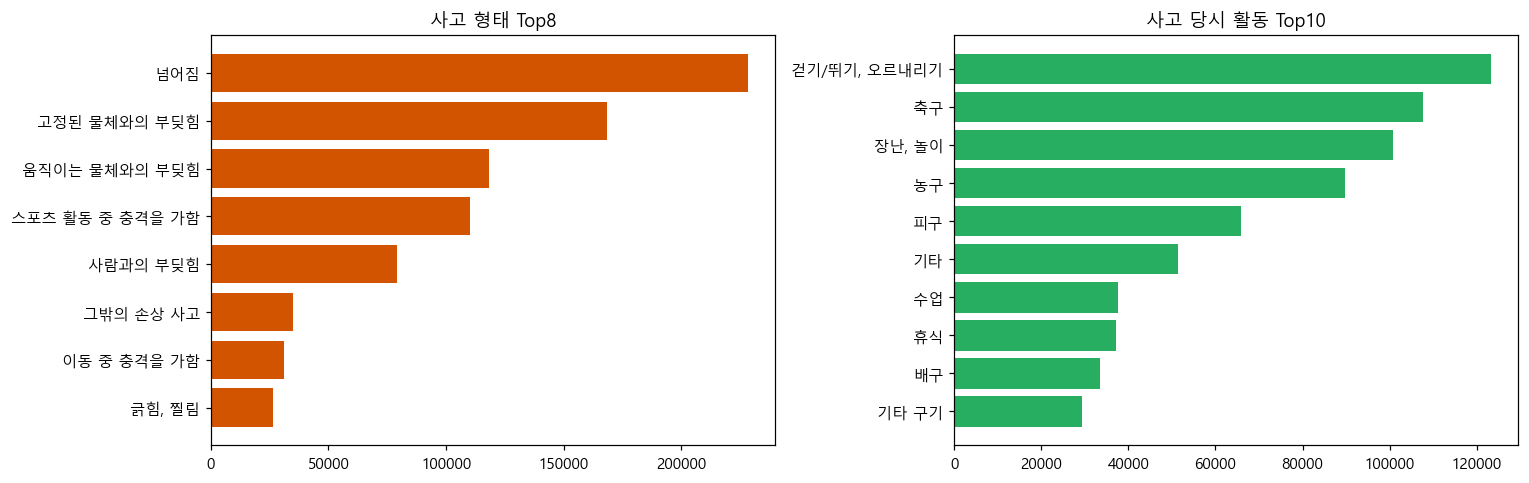

부딪힘 계열 합: 42.3%
구기(축구·농구·피구·배구) 합: 34.3%


In [13]:
# [그림8] 사고 형태 & 당시 활동 -> 넘어짐/부딪힘, 구기종목(축구·농구·피구)
fig, axes = plt.subplots(1,2, figsize=(14,4.5))
frm = occ['사고형태'].value_counts().head(8)[::-1]
axes[0].barh(frm.index, frm.values, color='#d35400'); axes[0].set_title('사고 형태 Top8')
act = occ['사고당시활동'].value_counts().head(10)[::-1]
axes[1].barh(act.index, act.values, color='#27ae60'); axes[1].set_title('사고 당시 활동 Top10')
plt.tight_layout(); save('fig08_형태_활동.png'); plt.show()
print('부딪힘 계열 합:', f"{occ['사고형태'].str.contains('부딪힘').mean()*100:.1f}%")
print('구기(축구·농구·피구·배구) 합:', f"{occ['사고당시활동'].isin(['축구','농구','피구','배구']).mean()*100:.1f}%")

> 형태는 **넘어짐(26%)·부딪힘 계열(42%)**, 활동은 **구기종목(축구·농구·피구·배구 약 34%)**. 예방 프로그램(준비운동·규칙·보호장비)의 우선 대상이 명확.

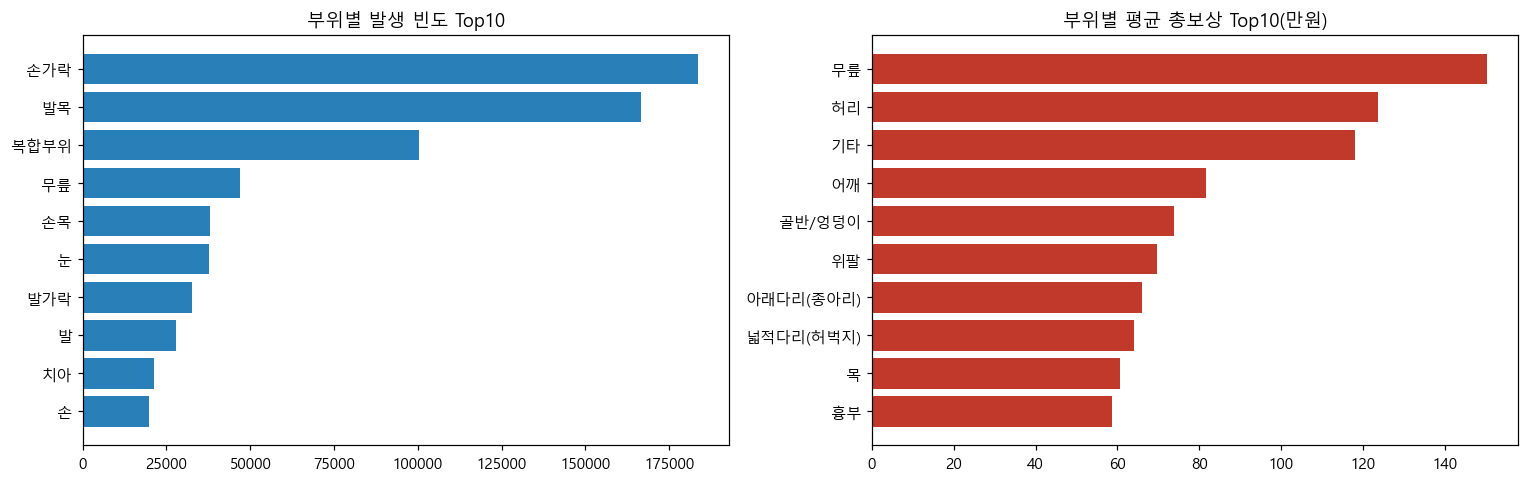

무릎 평균보상: 1,504,149원 | 발생 46,863건


In [14]:
# [그림9] 사고 부위: 빈도(손가락·발목) vs 평균보상(무릎) 분리
cnt_b = occ['사고부위'].value_counts().head(10)
avg_b = comp.groupby('사고부위')['총보상'].mean().reindex(cnt_b.index)
fig, axes = plt.subplots(1,2, figsize=(14,4.5))
axes[0].barh(cnt_b.index[::-1], cnt_b.values[::-1], color='#2980b9'); axes[0].set_title('부위별 발생 빈도 Top10')
avg_b2 = comp.groupby('사고부위')['총보상'].mean().sort_values(ascending=False).head(10)
axes[1].barh(avg_b2.index[::-1], (avg_b2.values/1e4)[::-1], color='#c0392b'); axes[1].set_title('부위별 평균 총보상 Top10(만원)')
plt.tight_layout(); save('fig09_부위.png'); plt.show()
print('무릎 평균보상:', f"{comp[comp['사고부위']=='무릎']['총보상'].mean():,.0f}원",
      '| 발생', f"{occ['사고부위'].eq('무릎').sum():,}건")

> 빈도는 **손가락·발목**(말단), 그러나 비용은 **무릎이 평균 150만원**으로 최고 — 스포츠성 인대·연골 손상 추정. '자주 다치는 곳'과 '비싸게 다치는 곳'이 다름.

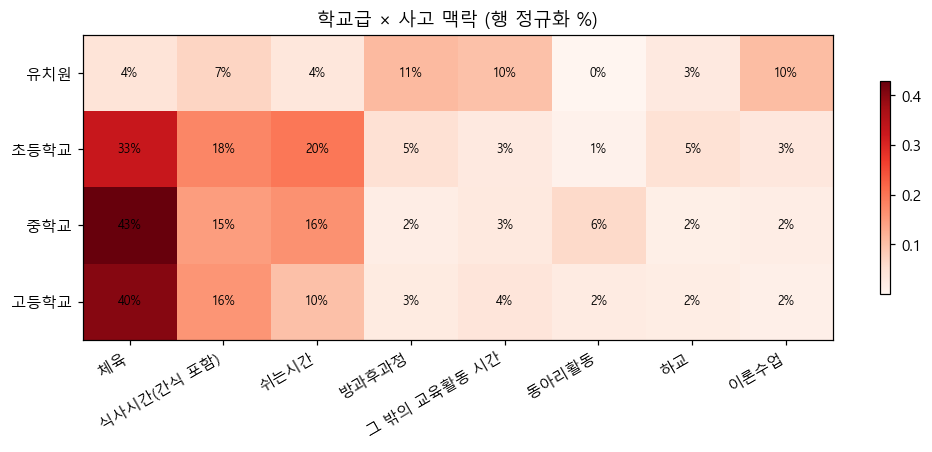

In [15]:
# [그림10] 교차분석 히트맵: 학교급 × 사고맥락(정규화) -> 학교급별 위험 활동 차이
top_ctx = occ['사고시간'].value_counts().head(8).index
ct = pd.crosstab(occ['학교급'], occ['사고시간'], normalize='index')[top_ctx].reindex(order[:4])
fig, ax = plt.subplots(figsize=(11,3.6))
im = ax.imshow(ct.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(top_ctx))); ax.set_xticklabels(top_ctx, rotation=30, ha='right')
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j,i,f'{ct.values[i,j]*100:.0f}%',ha='center',va='center',fontsize=8)
ax.set_title('학교급 × 사고 맥락 (행 정규화 %)'); fig.colorbar(im, shrink=0.7)
save('fig10_교차_학교급x맥락.png'); plt.show()

> 유치원은 체육수업이 없어 **방과후·식사·기타활동**에 사고가 분산되는 반면, 초·중·고는 **체육 비중(20→43%)**이 지배적. 학교급별 위험 맥락이 뚜렷이 다름 → 예방책도 학교급 맞춤이어야 함.

## 7. 보상 데이터 연계 — 심각도·비용 분석

In [16]:
# 급여 항목 구조: 요양급여가 건수의 대부분, 그러나 장해·유족급여가 '극단 비용'
MONEY = E.MONEY
summ = pd.DataFrame({
    '지급건수': [(comp[c]>0).sum() for c in MONEY],
    '합계(억원)': [comp[c].sum()/1e8 for c in MONEY],
    '지급건평균(만원)': [comp[c][comp[c]>0].mean()/1e4 if (comp[c]>0).any() else 0 for c in MONEY],
}, index=MONEY).round(1)
summ

,지급건수,합계(억원),지급건평균(만원)
요양급여,528090,1748.2,33.1
장해급여,518,505.5,9757.8
간병급여,24,4.2,1746.7
유족급여,25,91.6,36629.5
장례비,17,2.3,1370.1
위로금,10,4.2,4169.7
보전비용,42,1.1,268.8


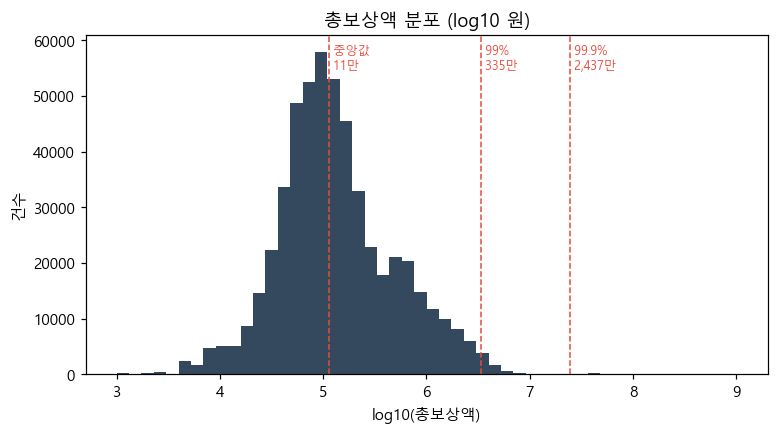

중앙값 114,000 | 상위1% 기준 3,351,000 | 최대 1,010,000,000


In [17]:
# [그림11] 총보상 분포(로그) -> 극심한 우편향: 중앙값 11.4만 vs 최대 10.1억
tot = comp['총보상']
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(np.log10(tot.clip(lower=1)), bins=50, color='#34495e')
for q,label in [(.5,'중앙값'),(.99,'99%'),(.999,'99.9%')]:
    v=tot.quantile(q); ax.axvline(np.log10(v), color='#e74c3c', ls='--', lw=1)
    ax.text(np.log10(v), ax.get_ylim()[1]*0.9, f' {label}\n {v/1e4:,.0f}만', fontsize=8, color='#e74c3c')
ax.set_title('총보상액 분포 (log10 원)'); ax.set_xlabel('log10(총보상액)'); ax.set_ylabel('건수')
save('fig12_보상분포.png'); plt.show()
print('중앙값', f'{tot.median():,.0f}', '| 상위1% 기준', f'{tot.quantile(.99):,.0f}', '| 최대', f'{tot.max():,.0f}')

> 보상액은 **극단적 우편향**: 절반이 11.4만원 이하지만 상위 극소수(장해·유족)가 총비용을 좌우. 예방의 경제적 효과는 **소수 고액사고 차단**에서 가장 큼.

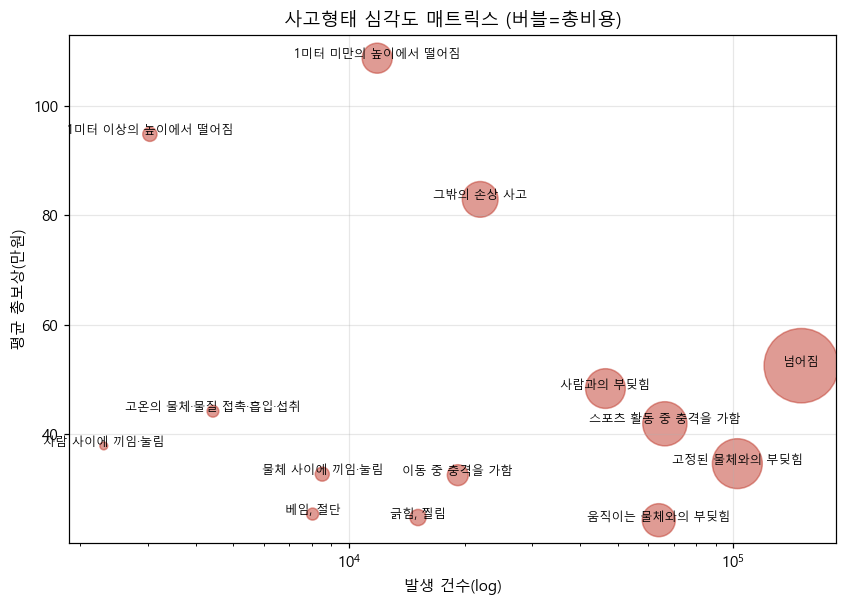

In [18]:
# [그림12] 심각도 매트릭스: 사고형태별 발생빈도(x) vs 평균보상(y), 버블=총비용
g = comp.groupby('사고형태').agg(건수=('총보상','size'), 평균=('총보상','mean'), 합계=('총보상','sum'))
g = g[g['건수']>=1000]
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(g['건수'], g['평균']/1e4, s=g['합계']/1e8*3, alpha=0.5, color='#c0392b')
for name,row in g.iterrows():
    ax.annotate(name, (row['건수'], row['평균']/1e4), fontsize=8, ha='center')
ax.set_xscale('log'); ax.set_xlabel('발생 건수(log)'); ax.set_ylabel('평균 총보상(만원)')
ax.set_title('사고형태 심각도 매트릭스 (버블=총비용)'); ax.grid(alpha=0.3)
save('fig13_심각도매트릭스.png'); plt.show()

> **우상단**(빈도·비용 모두 높음)=**넘어짐**은 최우선 예방 대상. **좌상단**(드물지만 고비용)=낙상(1m↑)·질식 등은 '저빈도 고위험'으로 별도 관리. 빈도만 보면 놓치는 위험을 비용축이 드러냄.

In [19]:
# 고액(상위 1%) 사고의 공통 특성 vs 전체 비교
thr = comp['총보상'].quantile(0.99)
hi = comp[comp['총보상']>=thr]
def share(df, col): return df[col].value_counts(normalize=True)
comp_tbl = pd.DataFrame({
    '학교급_고액%': share(hi,'학교급')*100, '학교급_전체%': share(comp,'학교급')*100,
}).round(1).sort_values('학교급_고액%', ascending=False)
print('고액사고 임계(상위1%):', f'{thr:,.0f}원, {len(hi):,}건')
print(comp_tbl.head())
print('\n[고액사고 활동 Top5]'); print((share(hi,'사고당시활동')*100).round(1).head())
print('\n[고액사고 형태 Top5]'); print((share(hi,'사고형태')*100).round(1).head())

고액사고 임계(상위1%): 3,351,000원, 5,291건
      학교급_고액%  학교급_전체%
학교급                   
고등학교     64.0     20.0
중학교      25.3     35.6
초등학교      8.2     37.0
기타학교      1.2      0.3
특수학교      0.8      0.4

[고액사고 활동 Top5]
사고당시활동
축구              26.9
농구              11.1
걷기/뛰기, 오르내리기    10.6
기타               6.0
장난, 놀이           5.1
Name: proportion, dtype: float64

[고액사고 형태 Top5]
사고형태
넘어짐                38.7
스포츠 활동 중 충격을 가함    21.3
사람과의 부딪힘           10.6
고정된 물체와의 부딪힘        8.5
그밖의 손상 사고           7.0
Name: proportion, dtype: float64


> 고액사고는 **고등학교·구기/무도 스포츠·낙상 계열** 비중이 전체보다 뚜렷이 높음. '심각한 사고'의 프로필이 '흔한 사고'와 구조적으로 다름을 보여줌.

## 8. 종합 인사이트 & 주제 후보

### 확인된 핵심 패턴
1. **회복 추세**: 발생 2021→2024 +123% (코로나 정상화). 사고 총량 증가 국면.
2. **체육 집중**: 맥락 '체육' 36% · 장소 체육관+운동장 56% · 활동 구기 34%. 학교안전 = 체육안전.
3. **시간 집중**: 학기중·평일·11~13시. 방학월 대비 학기월 3배.
4. **빈도 vs 심각도 분리**: 빈도(초·중/손가락·발목/넘어짐) ↔ 비용(고교/무릎/낙상·무도). 예방 타깃 이원화 필요.
5. **비용 극단 편중**: 중앙값 11.4만 vs 상위 장해·유족이 총비용 좌우.

### 예방 관점 주제 후보 (상세는 리포트 참조)
- (A) 체육활동 안전 — '언제·무슨 종목'이 위험한가
- (B) 빈도 대신 **심각도·비용 가중** 위험지도
- (C) 학교급별 맞춤 예방 (유치원 놀이 ↔ 고교 스포츠)
- (D) 코로나 후 사고 급증과 '안전 회복력'
- (E) 지역 위험도 정규화(학생 1천명당) + 취약지 도출

> 데이터 근거·수치·외부데이터 출처는 `Docs/EDA_요약리포트.md` 참조.